# EDA: Playground Series S6E3 vs IBM Telco Customer Churn

**Environment:** Select the `churn` conda kernel (or run `conda activate churn` before starting Jupyter). If imports fail, install once: `pip install pandas numpy matplotlib seaborn scipy ipykernel jupyter`.

Goals:
- Missing values: random vs systematic patterns  
- Feature distributions: spikes / synthetic artifacts  
- Target balance (churn rate)  
- **Train vs test:** do marginals match? (synthetic trap)  
- **Original IBM dataset:** same schema, calibrate expectations

Paths assume this notebook lives in `playground-series-s6e3/` and the original CSV is one level up.

In [1]:
from pathlib import Path

from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)

NOTEBOOK_DIR = Path.cwd().resolve()
if NOTEBOOK_DIR.name != "playground-series-s6e3":
    # If launched from repo root, point at competition folder
    comp = NOTEBOOK_DIR / "playground-series-s6e3"
    if comp.is_dir():
        NOTEBOOK_DIR = comp

ROOT = NOTEBOOK_DIR.parent
PATH_TRAIN = NOTEBOOK_DIR / "train.csv"
PATH_TEST = NOTEBOOK_DIR / "test.csv"
PATH_ORIG = ROOT / "WA_Fn-UseC_-Telco-Customer-Churn.csv"

for p in (PATH_TRAIN, PATH_TEST, PATH_ORIG):
    print(f"{'OK' if p.exists() else 'MISSING'}: {p}")

OK: /Users/elakkiya.r/projects/churn/playground-series-s6e3/train.csv
OK: /Users/elakkiya.r/projects/churn/playground-series-s6e3/test.csv
OK: /Users/elakkiya.r/projects/churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


## 1. Load data

Original IBM file uses `customerID` and sometimes has `TotalCharges` as text with blanks; competition uses numeric `id` and numeric `TotalCharges`.

In [2]:
train = pd.read_csv(PATH_TRAIN)
test = pd.read_csv(PATH_TEST)
orig = pd.read_csv(PATH_ORIG)

# Normalize original for alignment: id-like key + numeric TotalCharges
orig = orig.copy()
orig["id"] = orig["customerID"].astype(str)
orig["TotalCharges_num"] = pd.to_numeric(orig["TotalCharges"], errors="coerce")

print("Shapes:", {"train": train.shape, "test": test.shape, "original": orig.shape})
print("\nTrain columns:", list(train.columns))
print("Test has Churn:", "Churn" in test.columns)

Shapes: {'train': (594194, 21), 'test': (254655, 20), 'original': (7043, 23)}

Train columns: ['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
Test has Churn: False


In [3]:
feature_cols = [c for c in train.columns if c not in ("id", "Churn")]
num_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = [c for c in feature_cols if c not in num_cols]

train.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


## 2. Missing values

Check nulls and "silent" missing values (e.g. empty strings in the original `TotalCharges`).

In [4]:
def missing_report(df, name):
    m = df.isna().sum()
    m = m[m > 0].sort_values(ascending=False)
    print(f"=== {name}: NA count (columns with any NA) ===")
    print(m if len(m) else "No NA values")


missing_report(train, "train")
missing_report(test, "test")
missing_report(orig, "original")

orig_tc_blank = (orig["TotalCharges"].astype(str).str.strip() == "") | orig[
    "TotalCharges"
].isna()
print(
    f"\nOriginal: blank/NA TotalCharges (often tenure=0): {orig_tc_blank.sum()} rows"
)
if orig_tc_blank.any():
    display(orig.loc[orig_tc_blank, ["tenure", "TotalCharges", "MonthlyCharges"]].head(10))

=== train: NA count (columns with any NA) ===
No NA values
=== test: NA count (columns with any NA) ===
No NA values
=== original: NA count (columns with any NA) ===
TotalCharges_num    11
dtype: int64

Original: blank/NA TotalCharges (often tenure=0): 11 rows


,tenure,TotalCharges,MonthlyCharges
488,0,,52.55
753,0,,20.25
936,0,,80.85
1082,0,,25.75
1340,0,,56.05
3331,0,,19.85
3826,0,,25.35
4380,0,,20.00
5218,0,,19.70
6670,0,,73.35


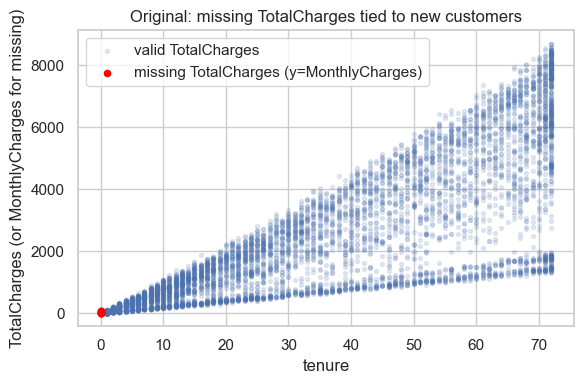

In [5]:
# Systematic check: NA or invalid TotalCharges vs tenure (original only)
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(
    orig.loc[~orig_tc_blank, "tenure"],
    orig.loc[~orig_tc_blank, "TotalCharges_num"],
    alpha=0.15,
    s=8,
    label="valid TotalCharges",
)
if orig_tc_blank.any():
    ax.scatter(
        orig.loc[orig_tc_blank, "tenure"],
        orig.loc[orig_tc_blank, "MonthlyCharges"],
        c="red",
        s=20,
        label="missing TotalCharges (y=MonthlyCharges)",
    )
ax.set_xlabel("tenure")
ax.set_ylabel("TotalCharges (or MonthlyCharges for missing)")
ax.legend()
ax.set_title("Original: missing TotalCharges tied to new customers")
plt.tight_layout()
plt.show()

## 3. Target balance

Competition metric is typically AUC-ROC; class imbalance still matters for interpretation.

train (competition): churn rate = 22.52%  (n=594,194)
original IBM: churn rate = 26.54%  (n=7,043)


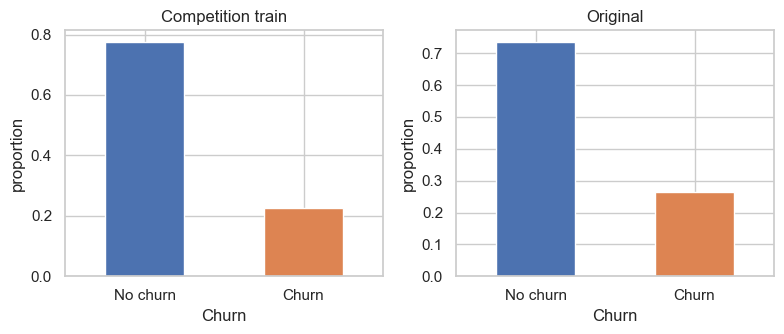

In [6]:
def churn_to_binary(s):
    if pd.api.types.is_numeric_dtype(s):
        return s.astype(int)
    m = {"Yes": 1, "No": 0, "True": 1, "False": 0, True: 1, False: 0}
    return s.astype(str).map(m).astype(float).astype(int)


y_train = churn_to_binary(train["Churn"])
y_orig = churn_to_binary(orig["Churn"])

for name, y in [("train (competition)", y_train), ("original IBM", y_orig)]:
    rate = y.mean()
    print(f"{name}: churn rate = {rate:.2%}  (n={len(y):,})")

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
for ax, (name, y) in zip(
    axes,
    [("Competition train", y_train), ("Original", y_orig)],
):
    y.value_counts(normalize=True).sort_index().plot(kind="bar", ax=ax, color=["#4c72b0", "#dd8452"])
    ax.set_xticklabels(["No churn", "Churn"], rotation=0)
    ax.set_ylabel("proportion")
    ax.set_title(name)
plt.tight_layout()
plt.show()

## 4. Numeric feature distributions (histograms)

Look for unnatural spikes / quantization when compared to the original sample.

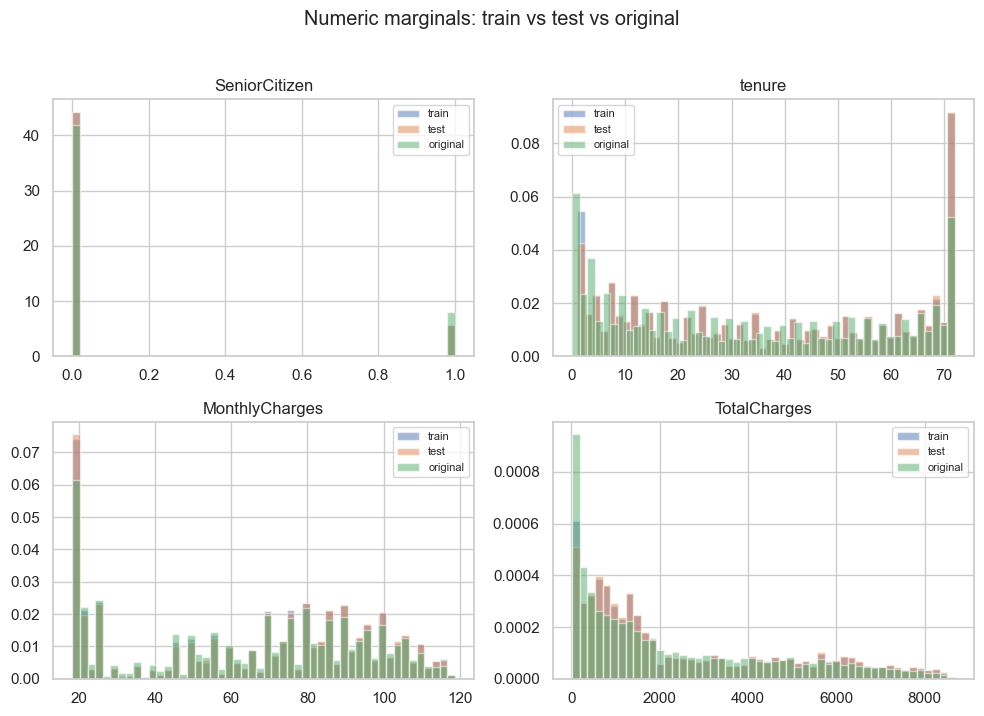

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.ravel()
for ax, col in zip(axes, num_cols):
    ax.hist(train[col].dropna(), bins=50, alpha=0.5, density=True, label="train")
    ax.hist(test[col].dropna(), bins=50, alpha=0.5, density=True, label="test")
    if col == "TotalCharges":
        sub = orig["TotalCharges_num"].dropna()
    else:
        sub = orig[col].dropna()
    ax.hist(sub, bins=50, alpha=0.5, density=True, label="original")
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.suptitle("Numeric marginals: train vs test vs original", y=1.02)
plt.tight_layout()
plt.show()

## 5. Categorical features — level frequencies

Compare category mixes between train and test (and original) to spot distribution shift.

,feature,train_vs_test_L1,train_vs_orig_L1
1,Partner,0.007998,0.037932
14,PaymentMethod,0.007564,0.035584
12,Contract,0.007453,0.073952
7,OnlineBackup,0.006977,0.020168
11,StreamingMovies,0.006071,0.038588
9,TechSupport,0.005998,0.020168
6,OnlineSecurity,0.005370,0.020168
10,StreamingTV,0.005333,0.040230
8,DeviceProtection,0.005085,0.023120
4,MultipleLines,0.005003,0.040148


Largest train–test categorical shift (by L1): Partner


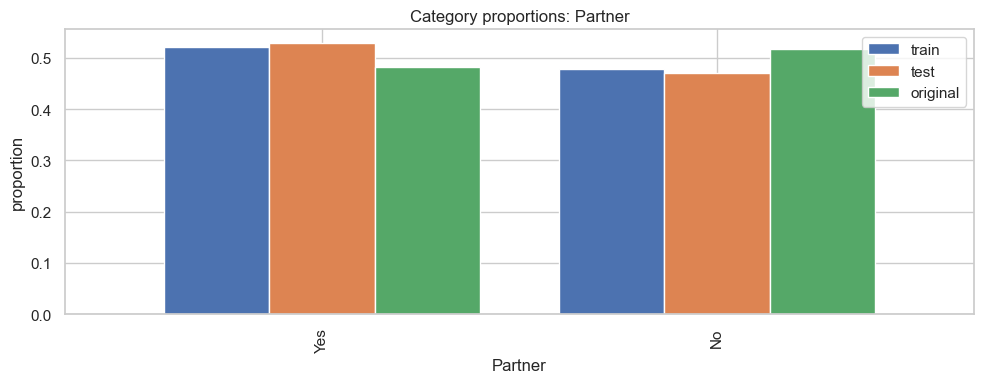

In [8]:
def l1_dist_categorical(s1, s2, topn=50):
    """L1 distance between normalized value counts (union of categories)."""
    c1 = s1.astype(str).value_counts(normalize=True)
    c2 = s2.astype(str).value_counts(normalize=True)
    idx = c1.index.union(c2.index)
    p = c1.reindex(idx, fill_value=0)
    q = c2.reindex(idx, fill_value=0)
    return float((p - q).abs().sum() / 2)


rows = []
for c in cat_cols:
    rows.append(
        {
            "feature": c,
            "train_vs_test_L1": l1_dist_categorical(train[c], test[c]),
            "train_vs_orig_L1": l1_dist_categorical(train[c], orig[c]),
        }
    )
cat_shift = pd.DataFrame(rows).sort_values("train_vs_test_L1", ascending=False)
display(cat_shift.head(15))

worst = cat_shift.iloc[0]["feature"]
print(f"Largest train–test categorical shift (by L1): {worst}")

ct_tr = train[worst].astype(str).value_counts(normalize=True)
ct_te = test[worst].astype(str).value_counts(normalize=True)
ct_or = orig[worst].astype(str).value_counts(normalize=True)
cmp = pd.concat(
    [ct_tr, ct_te, ct_or], axis=1, keys=["train", "test", "original"]
).fillna(0)
cmp.plot(kind="bar", figsize=(10, 4), width=0.8)
plt.title(f"Category proportions: {worst}")
plt.ylabel("proportion")
plt.tight_layout()
plt.show()

## 6. Train vs test (numeric) — two-sample tests on a subsample

Full files are large; we subsample for speed. Small p-values suggest marginals differ (possible synthetic artifacts or intentional resampling).

In [9]:
rng = np.random.default_rng(42)
n_sub = min(50000, len(train), len(test))
idx_tr = rng.choice(len(train), size=n_sub, replace=False)
idx_te = rng.choice(len(test), size=n_sub, replace=False)

results = []
for col in num_cols:
    a = train[col].iloc[idx_tr].dropna().values
    b = test[col].iloc[idx_te].dropna().values
    stat, p = stats.ks_2samp(a, b)
    results.append({"feature": col, "KS_stat": stat, "p_value": p})
pd.DataFrame(results)

,feature,KS_stat,p_value
0,SeniorCitizen,0.00262,9.952759e-01
1,tenure,0.01800,1.818877e-07
2,MonthlyCharges,0.00640,2.563425e-01
3,TotalCharges,0.01686,1.327988e-06


## 7. Quick sanity: MonthlyCharges vs TotalCharges / tenure

Engineered ratios can be predictive; first inspect linear structure and outliers.

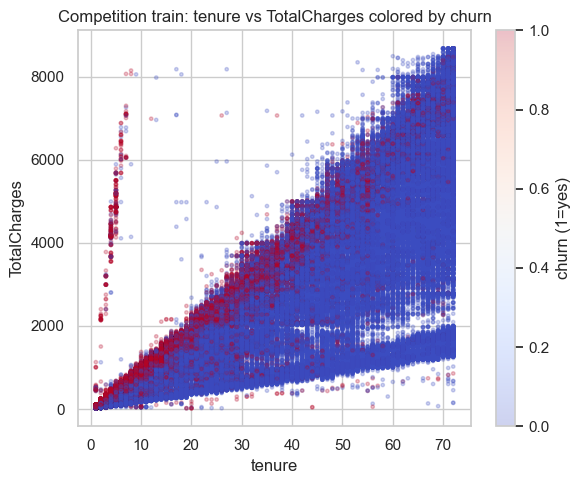

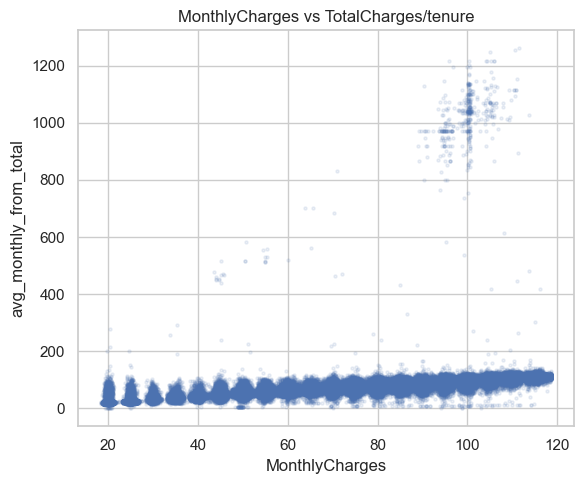

In [10]:
train_fe = train.copy()
train_fe["avg_monthly_from_total"] = train_fe["TotalCharges"] / train_fe["tenure"].replace(
    0, np.nan
)
train_fe["monthly_x_tenure"] = train_fe["MonthlyCharges"] * train_fe["tenure"]

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(
    train_fe["tenure"],
    train_fe["TotalCharges"],
    c=y_train,
    cmap="coolwarm",
    alpha=0.25,
    s=6,
)
plt.colorbar(sc, ax=ax, label="churn (1=yes)")
ax.set_xlabel("tenure")
ax.set_ylabel("TotalCharges")
ax.set_title("Competition train: tenure vs TotalCharges colored by churn")
plt.tight_layout()
plt.show()

train_fe[["MonthlyCharges", "avg_monthly_from_total"]].dropna().plot(
    kind="scatter", x="MonthlyCharges", y="avg_monthly_from_total", alpha=0.1, s=5, figsize=(6, 5)
)
plt.title("MonthlyCharges vs TotalCharges/tenure")
plt.tight_layout()
plt.show()

## 8. Summary checklist (for modeling later)

- **Leakage:** `Churn` only in train; test has no labels — do not use target-derived features fit on full data without CV inside folds.  
- **Imbalance:** rely on AUC / PR and proper CV, not plain accuracy.  
- **Synthetic data:** if train/test marginals differ sharply, trust local CV; avoid leaderboard overfitting.  
- **Next steps:** OHE / target encoding, GBDT baselines (XGBoost, LightGBM, CatBoost), stratified K-fold.